#Background Removal Using Neural Networks

This notebook explores background estimation and removal in synthetic radio astronomy spectra using deep learning techniques.

The main objective is to train a neural network capable of estimating the smooth background component of a spectrum while ignoring spectral lines and noise.

The workflow includes:

1. Synthetic spectrum generation
2. Signal preprocessing
3. Dataset construction
4. TensorFlow model development
5. Training and evaluation
6. Background subtraction analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from enum import Enum

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Step 1 — Global Configuration

In this step we configure the global environment of the notebook.

The main objectives are:
- ensuring reproducibility
- configuring plotting settings
- verifying the TensorFlow installation

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1 Summary

In this step we configured the notebook environment and initialized reproducibility settings.

Random seeds were fixed for both NumPy and TensorFlow in order to ensure stable and repeatable experiments.

Additionally, default plotting settings were configured to improve visualization consistency throughout the notebook.

# Step 2 — Frequency Axis Generation and Visualization

In this step we generate the synthetic frequency axis that will be used throughout the project.

The selected frequency range is centered near the hydrogen line region around 1420 MHz.

After generating the frequency axis, we visualize it in order to verify:
- the correct number of spectral channels
- the selected frequency range
- the uniform spacing of the samples

In [ ]:
NUM_CHANNELS = 1024

FREQ_MIN = 1419.0
FREQ_MAX = 1421.0

freq = np.linspace(FREQ_MIN, FREQ_MAX, NUM_CHANNELS)

print("Frequency axis shape:", freq.shape)
print("Minimum frequency:", freq.min(), "MHz")
print("Maximum frequency:", freq.max(), "MHz")

Frequency axis shape: (1024,)
Minimum frequency: 1419.0 MHz
Maximum frequency: 1421.0 MHz


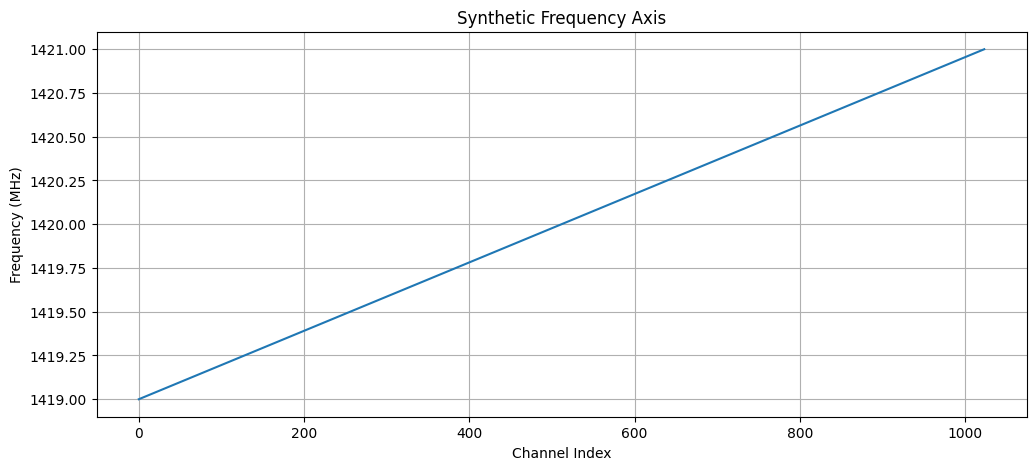

In [ ]:
plt.plot(freq)

plt.title("Synthetic Frequency Axis")
plt.xlabel("Channel Index")
plt.ylabel("Frequency (MHz)")

plt.show()

## Step 2 Summary

In this step we generated and visualized the synthetic frequency axis used throughout the entire project.

The generated axis contains 1024 uniformly spaced spectral channels between 1419 MHz and 1421 MHz.

This frequency range is centered near the neutral hydrogen spectral line

# Step 3 — Noise Generation

In this step we generate synthetic Gaussian noise.

Noise is an unavoidable component of real radio astronomy observations and originates from several sources, including:

- receiver electronics,
- thermal fluctuations,
- environmental effects,
- random measurement variations.

For the first version of the pipeline, we assume that noise follows a Gaussian distribution with zero mean.

In [ ]:
NOISE_STD = 0.01

noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=NUM_CHANNELS
)

print(f"Noise shape: {noise.shape}")
print(f"Noise mean: {np.mean(noise):.6f}")
print(f"Noise standard deviation: {np.std(noise):.6f}")

Noise shape: (1024,)
Noise mean: 0.000294
Noise standard deviation: 0.009781


## Noise Visualization

Before using the generated noise in the synthetic spectrum pipeline, it is useful to visualize its behavior.

The noise should fluctuate randomly around zero without exhibiting any obvious trend or structure.

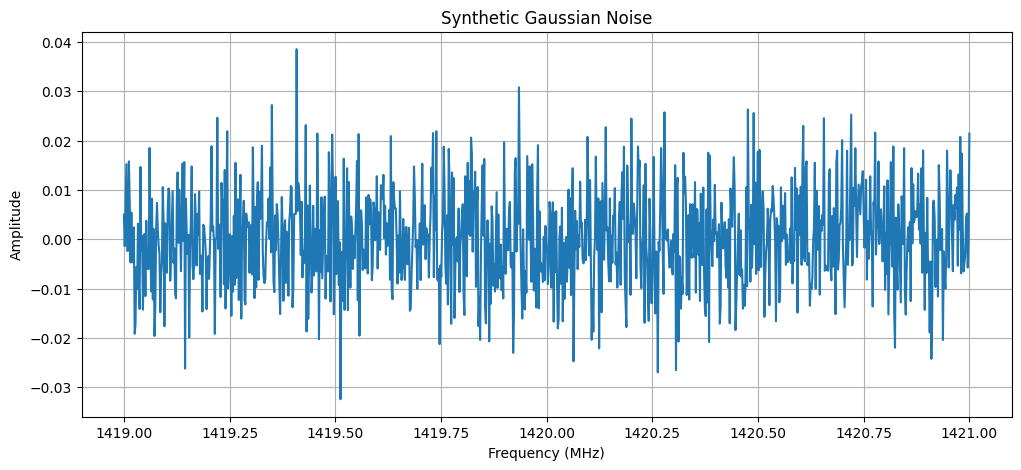

In [ ]:
plt.plot(freq, noise)

plt.title("Synthetic Gaussian Noise")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Noise Distribution

A histogram provides a simple way to verify that the generated samples approximately follow a Gaussian distribution.

The distribution should be centered around zero and spread according to the selected standard deviation.

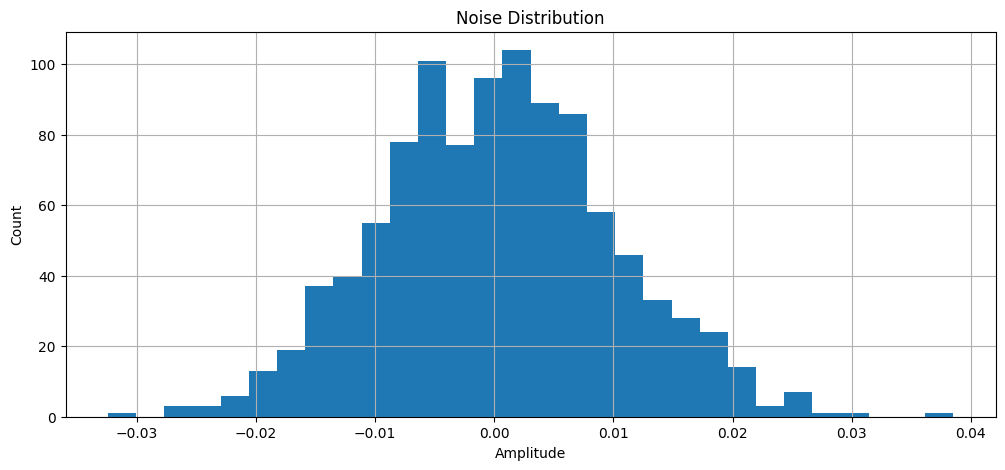

In [ ]:
plt.hist(noise, bins=30)

plt.title("Noise Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")

plt.show()

## Step 3 Summary

In this step we generated a synthetic Gaussian noise signal with zero mean and a standard deviation of 0.01.

The generated noise contains one value for each spectral channel.

This component will be incorporated into the background generation process and the final synthetic observations.

# Step 4 — Background Baseline Generation

According to the synthetic signal generation procedure described in the project guideline, the first component of the background is a constant baseline level.

The original PICTOR implementation generates a random offset between 0.8 and 1.1 before introducing any polynomial bandpass distortions or standing-wave ripples.

In this step we reproduce that behavior and initialize the background signal using only the baseline component.

This allows us to validate each background component independently before constructing the complete synthetic background model.

In [ ]:
baseline_level = np.random.uniform(
    low=0.8,
    high=1.1
)

background = np.full_like(
    freq,
    fill_value=baseline_level
)

print(f"Baseline level: {baseline_level:.4f}")
print(f"Background shape: {background.shape}")

Baseline level: 0.9666
Background shape: (1024,)


## Baseline Visualization

The current background contains only a constant DC offset.

This visualization helps verify that the baseline has the correct amplitude and extends across the full frequency range.

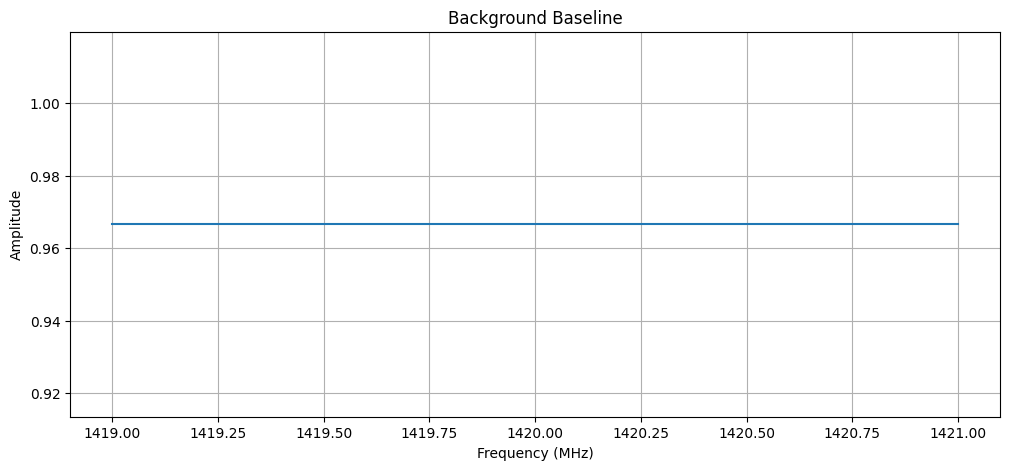

In [ ]:
plt.plot(freq, background)

plt.title("Background Baseline")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 4 Summary

The background signal has been initialized using a constant baseline level sampled from the range specified in the project guideline.

At this stage the background contains only the DC offset component.


# Step 5 — Background Distortion Configuration

The synthetic background generation procedure supports different large-scale background morphologies.

Three distortion configurations are defined:

- `POLY` for polynomial bandpass variation,
- `SIN` for standing-wave ripple,
- `BOTH` for a combination of the two components.

Before generating these components, the frequency axis is normalized to the interval [-1, 1]. The normalized coordinate is used directly in the polynomial and sinusoidal background equations.

In [ ]:
class SignalType(Enum):
    POLY = 1
    SIN = 2
    BOTH = 3

In [ ]:
x_norm = (
    2 * (freq - np.min(freq))
    / (np.max(freq) - np.min(freq))
    - 1
)

print(f"Normalized frequency minimum: {x_norm.min():.2f}")
print(f"Normalized frequency maximum: {x_norm.max():.2f}")

Normalized frequency minimum: -1.00
Normalized frequency maximum: 1.00


In [ ]:
possible_signals = [
    SignalType.POLY,
    SignalType.SIN,
    SignalType.BOTH
]

signal_type = np.random.choice(
    possible_signals,
    p=[0.2, 0.1, 0.7]
)

print(f"Selected distortion type: {signal_type.name}")

Selected distortion type: BOTH


## Step 5 Summary

The background distortion configuration has been defined using the three signal types required by the synthetic generation procedure.

The frequency axis was normalized to [-1, 1] and a distortion configuration was selected using the predefined probability distribution.

The selected signal type will control whether the synthetic background receives a polynomial component, a sinusoidal ripple, or both in the following steps.

# Step 6 — Polynomial Bandpass Component

The polynomial component introduces the smooth large-scale bandpass variation of the synthetic background.

Following the selected distortion configuration, this component is generated only for `POLY` and `BOTH` background types.

The polynomial is defined using the normalized frequency axis and contains:

- a curvature term controlling the overall U-shaped or hill-shaped morphology,
- a slope term introducing a gradual linear variation across the spectrum.

The parameter ranges follow the PICTOR-inspired synthetic generation procedure.

In [ ]:
poly_component = np.zeros_like(freq)

if signal_type in (SignalType.POLY, SignalType.BOTH):
    curvature = np.random.uniform(-0.02, 0.08)
    slope = np.random.uniform(-0.03, 0.03)

    poly_component = (
        curvature * x_norm**2
        + slope * x_norm
    )

    print(f"Curvature: {curvature:.4f}")
    print(f"Slope: {slope:.4f}")

else:
    print("Polynomial component skipped for SIN distortion type.")

Curvature: 0.0028
Slope: 0.0298


## Polynomial Component Visualization

The polynomial component is visualized independently before being combined with the baseline.

This makes it possible to inspect the large-scale morphology introduced by the sampled curvature and slope parameters.

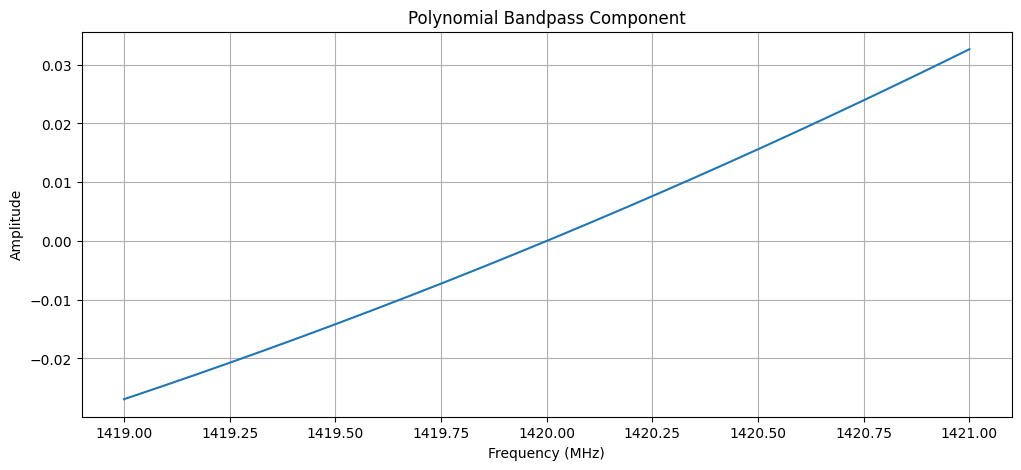

In [ ]:
plt.plot(freq, poly_component)

plt.title("Polynomial Bandpass Component")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Polynomial Background Combination

The generated polynomial component is now combined with the baseline background.

A separate background variable is retained at this stage so that each synthetic component remains independently traceable throughout the generation pipeline.

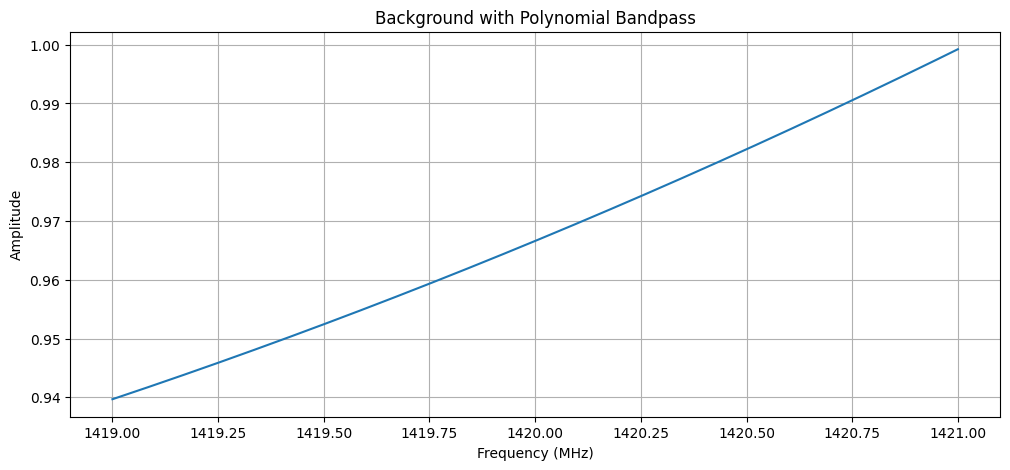

In [ ]:
background_with_poly = background + poly_component

plt.plot(freq, background_with_poly)

plt.title("Background with Polynomial Bandpass")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 6 Summary

The polynomial bandpass component has been generated according to the selected background distortion type.

For `POLY` and `BOTH` configurations, random curvature and slope parameters were sampled from the ranges defined in the synthetic signal procedure.

The polynomial component was then combined with the baseline while remaining separately available for component-level inspection.

The resulting background now includes the smooth large-scale bandpass variation required for PICTOR-like spectrum generation.

# Step 7 — Standing-Wave Ripple Component

The second distortion component models the standing-wave ripple present in PICTOR-like backgrounds.

According to the selected background configuration, the sinusoidal component is generated only for `SIN` and `BOTH` distortion types.

The ripple amplitude is kept small relative to the baseline, while the number of cycles is restricted to produce broad oscillations across the full spectrum rather than high-frequency variations.

A random phase is also introduced so that the ripple morphology does not begin at the same position in every generated spectrum.

In [ ]:
sin_component = np.zeros_like(freq)

if signal_type in (SignalType.SIN, SignalType.BOTH):
    ripple_amplitude = np.random.uniform(0.005, 0.01)
    cycles = np.random.uniform(0.5, 3.0)
    phase = np.random.uniform(0, 2 * np.pi)

    sin_component = ripple_amplitude * np.sin(
        cycles * np.pi * x_norm + phase
    )

    print(f"Ripple amplitude: {ripple_amplitude:.4f}")
    print(f"Cycles: {cycles:.4f}")
    print(f"Phase: {phase:.4f} rad")

else:
    print("Sinusoidal component skipped for POLY distortion type.")

Ripple amplitude: 0.0099
Cycles: 2.1258
Phase: 1.2538 rad


## Ripple Component Visualization

The sinusoidal component is inspected independently before being added to the existing background.

This visualization verifies that the generated ripple remains a low-amplitude, broad oscillation across the frequency range.

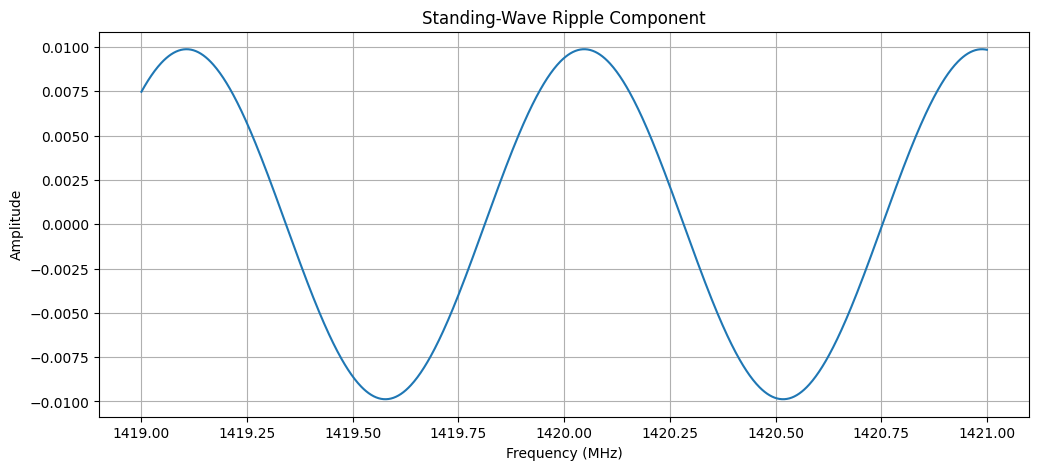

In [ ]:
plt.plot(freq, sin_component)

plt.title("Standing-Wave Ripple Component")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Background Component Combination

The standing-wave ripple is now added to the background produced in the previous step.

Because inactive distortion components are represented by zero-valued arrays, the same combination procedure can be used for all three background configurations.

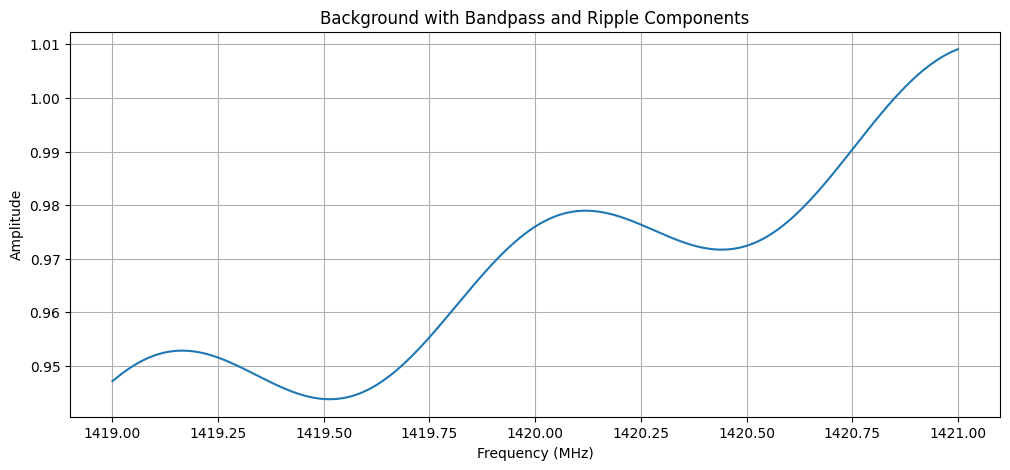

In [ ]:
background_with_ripple = background_with_poly + sin_component

plt.plot(freq, background_with_ripple)

plt.title("Background with Bandpass and Ripple Components")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 7 Summary

The standing-wave ripple component has been generated for `SIN` and `BOTH` background configurations.

Its amplitude, oscillation scale, and phase were randomly sampled from the ranges defined in the PICTOR-inspired generation procedure.

The sinusoidal component was then combined with the existing background pipeline.

At this stage, the synthetic background contains the baseline and the distortion components selected by the current background configuration.

# Step 8 — Final Synthetic Background Generation

The final stage of the background generation pipeline incorporates the noise signal created in Step 3.

At this point, the deterministic background structure has already been constructed from the baseline and the distortion components selected by `signal_type`.

The previously generated Gaussian noise is now added to this structure, reproducing the final output of the PICTOR-inspired background generation procedure.

The resulting signal will be retained as the synthetic background used in the following spectral-line generation stage.

In [ ]:
final_background = background_with_ripple + noise

print(f"Final background shape: {final_background.shape}")
print(f"Final background mean: {np.mean(final_background):.6f}")
print(f"Final background standard deviation: {np.std(final_background):.6f}")

Final background shape: (1024,)
Final background mean: 0.968402
Final background standard deviation: 0.020865


## Final Background Visualization

The completed synthetic background is now visualized across the frequency range.

This plot represents the combined output of the baseline, the selected large-scale distortion components, and the Gaussian noise contribution.

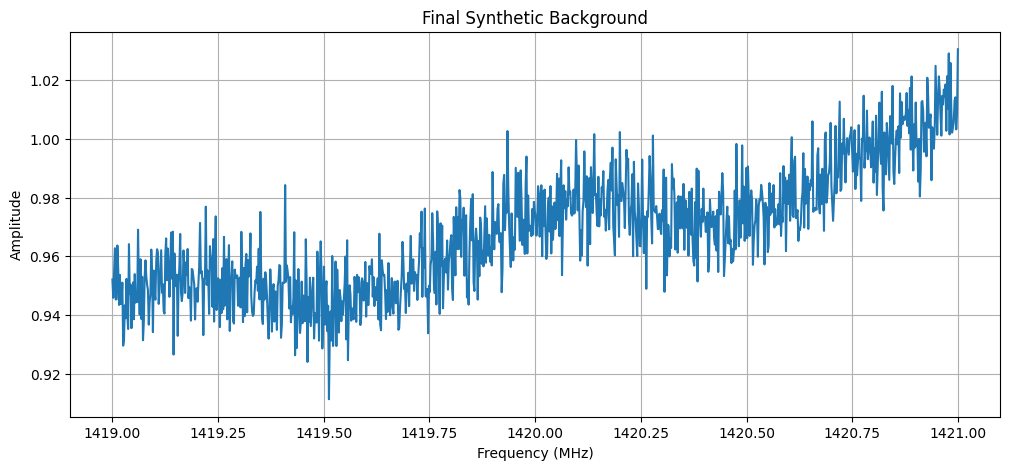

In [ ]:
plt.plot(freq, final_background)

plt.title("Final Synthetic Background")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Background Generation Comparison

To verify the contribution of each stage, the intermediate background signals are compared with the final noisy background.

This comparison provides a direct view of how the constant baseline is progressively transformed by the selected distortion components and the final noise contribution.

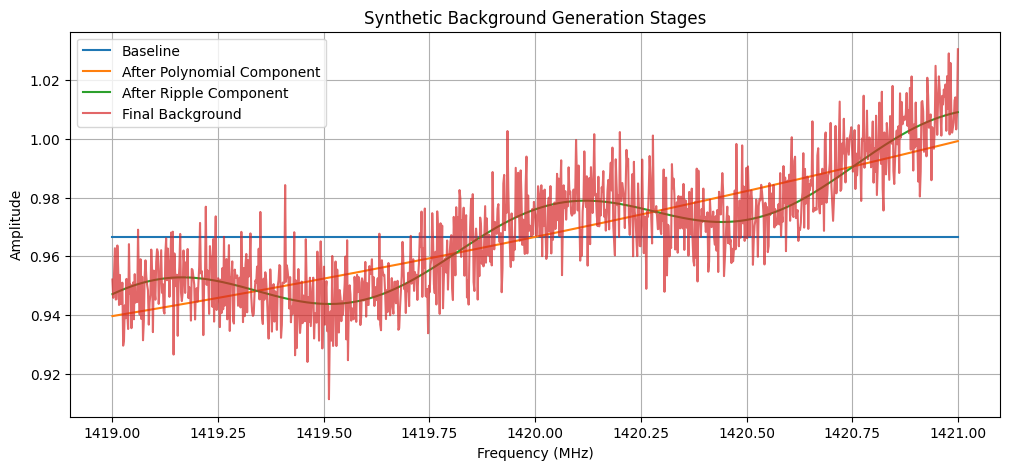

In [ ]:
plt.plot(freq, background, label="Baseline")
plt.plot(freq, background_with_poly, label="After Polynomial Component")
plt.plot(freq, background_with_ripple, label="After Ripple Component")
plt.plot(freq, final_background, label="Final Background", alpha=0.7)

plt.title("Synthetic Background Generation Stages")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 8 Summary

The synthetic background generation pipeline has been completed by adding the previously generated Gaussian noise.

The final background combines:

- the randomly sampled baseline level,
- the polynomial bandpass component when enabled,
- the standing-wave ripple when enabled,
- the Gaussian noise contribution.

The intermediate and final background signals were also compared to verify the progressive construction of the synthetic PICTOR-like background.

The completed background can now be used as the base signal for synthetic spectral-line generation.

# Step 9 — Main Spectral Peak Generation

The synthetic spectral-line generation stage begins with the construction of the main emission peak.

The spectral-line array is initialized independently from the previously generated background. For each requested spectral line, the central frequency is sampled between 1420.3 and 1420.7 MHz.

The peak width is controlled by a randomly sampled Gaussian standard deviation, while its amplitude is scaled relative to the measured standard deviation of the generated noise.

This SNR-based amplitude definition keeps the spectral-line strength directly linked to the noise conditions of the current synthetic observation.

In [ ]:
NUM_SPECTRAL_LINES = 1

noise_std = np.std(noise)

spectral_lines = np.zeros_like(freq)

print(f"Number of spectral lines: {NUM_SPECTRAL_LINES}")
print(f"Measured noise standard deviation: {noise_std:.6f}")

Number of spectral lines: 1
Measured noise standard deviation: 0.009781


## Main Peak Parameter Sampling

Each main peak is modeled using a Gaussian profile.

The center, width, and signal-to-noise ratio are sampled independently within the ranges defined by the synthetic signal procedure.

The sampled SNR is converted into a peak amplitude using the measured noise standard deviation.

In [ ]:
for _ in range(NUM_SPECTRAL_LINES):
    # Sample the main spectral-line center
    center_mean = np.random.uniform(1420.3, 1420.7)

    # Sample the Gaussian width and signal-to-noise ratio
    main_sigma = np.random.uniform(0.03, 0.045)
    main_snr = np.random.uniform(1.2, 8.0)

    # Scale the peak amplitude relative to the measured noise level
    main_amp = main_snr * noise_std

    # Generate the main Gaussian peak
    main_line = main_amp * np.exp(
        -((freq - center_mean) ** 2)
        / (2 * main_sigma**2)
    )

    spectral_lines += main_line

print(f"Center frequency: {center_mean:.4f} MHz")
print(f"Main sigma: {main_sigma:.4f}")
print(f"Main SNR: {main_snr:.4f}")
print(f"Main amplitude: {main_amp:.6f}")

Center frequency: 1420.5721 MHz
Main sigma: 0.0311
Main SNR: 1.4084
Main amplitude: 0.013776


## Main Spectral Peak Visualization

The generated main peak is visualized independently from the background.

At this stage, the spectral-line morphology is intentionally symmetric because only the primary Gaussian component has been generated.

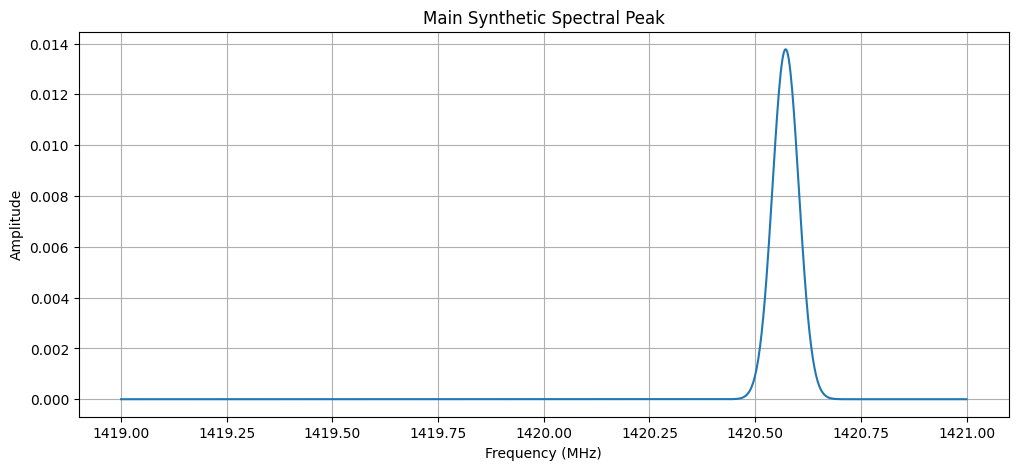

In [ ]:
plt.plot(freq, spectral_lines)

plt.title("Main Synthetic Spectral Peak")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Step 9 Summary

The spectral-line generation pipeline has been initialized and the main Gaussian peak has been constructed.

The peak center and width were randomly sampled from the ranges defined by the PICTOR-inspired procedure.

Its amplitude was determined from the sampled SNR and the measured standard deviation of the generated noise, directly linking the spectral-line strength to the noise level of the current synthetic observation.

At this stage, the spectral line contains only the symmetric main peak.

# Step 10 — Secondary Gaussian Component Generation

The main Gaussian peak generated in the previous step produces a smooth and symmetric spectral-line profile.

The synthetic signal procedure introduces additional Gaussian components near the primary peak to create a more irregular and asymmetric morphology.

Each secondary component is independently shifted from the main peak center and assigned its own width and amplitude.

The amplitude of each component is defined as a fraction of the main peak amplitude, ensuring that the primary spectral component remains dominant.

These secondary Gaussian components are generated as a synthetic morphology mechanism and are not related to antenna sidelobes.

In [ ]:
num_secondary_components = np.random.randint(3, 7)

secondary_components = np.zeros_like(freq)

for _ in range(num_secondary_components):
    # Sample a local shift relative to the main peak center
    offset = np.random.normal(
        loc=-main_sigma * 0.8,
        scale=main_sigma * 0.8
    )

    secondary_mean = center_mean + offset

    # Sample the component width and relative amplitude
    secondary_sigma = np.random.uniform(0.02, 0.04)
    secondary_amp = (
        np.random.uniform(0.3, 0.6)
        * main_amp
    )

    # Generate the secondary Gaussian component
    secondary_line = secondary_amp * np.exp(
        -((freq - secondary_mean) ** 2)
        / (2 * secondary_sigma**2)
    )

    secondary_components += secondary_line

print(
    f"Number of secondary Gaussian components: "
    f"{num_secondary_components}"
)

Number of secondary Gaussian components: 3


## Secondary Component Visualization

The secondary Gaussian components are visualized independently before being combined with the main spectral peak.

This allows the additional local spectral structure to be inspected separately from the dominant Gaussian component.

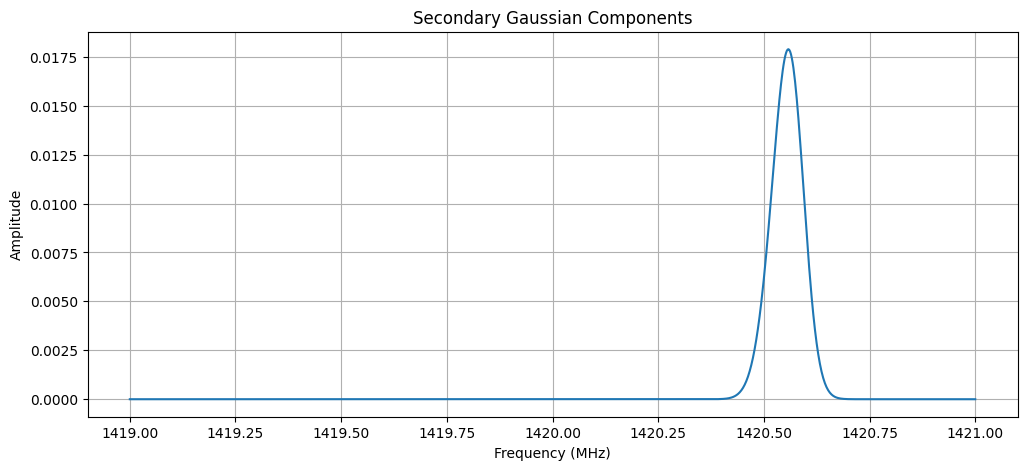

In [ ]:
plt.plot(freq, secondary_components)

plt.title("Secondary Gaussian Components")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Spectral-Line Component Combination

The secondary Gaussian components are now added to the main spectral peak.

The resulting profile preserves the dominant primary component while introducing local asymmetry and additional spectral structure.

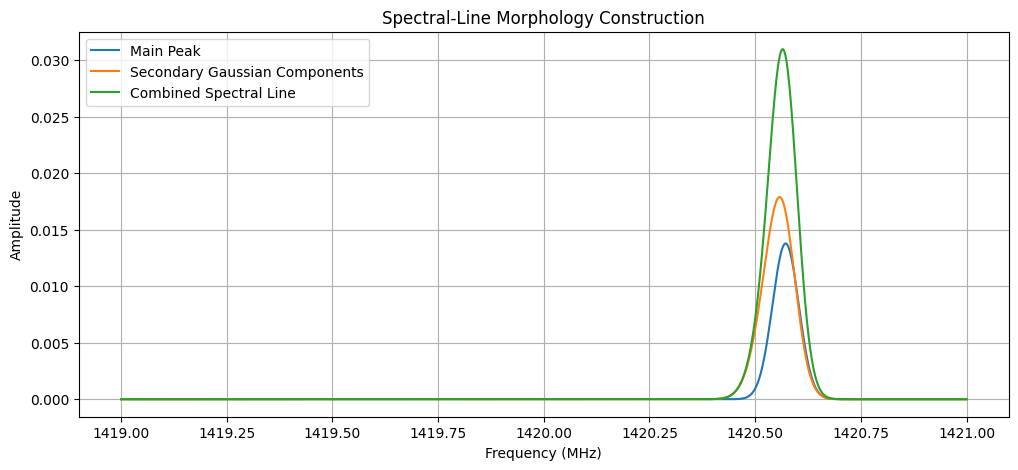

In [ ]:
spectral_lines += secondary_components

plt.plot(freq, main_line, label="Main Peak")

plt.plot(freq, secondary_components, label="Secondary Gaussian Components")

plt.plot(freq, spectral_lines, label="Combined Spectral Line")

plt.title("Spectral-Line Morphology Construction")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

## Step 10 Summary

Several secondary Gaussian components were generated near the main spectral peak.

Each component was assigned an independently sampled center offset, width, and relative amplitude.

The secondary components were then combined with the main Gaussian peak, transforming the original symmetric profile into a more irregular and asymmetric synthetic spectral line.

The resulting morphology follows the multi-component spectral-line construction defined in the PICTOR-inspired generation procedure.